# Семинар 13: Случайный лес

## 1. Bias-Variance decomposition

Вспомним, что функцию потерь в задачах регрессии или классификации можно разложить на три компоненты: смещение (bias), дисперсию (variance) и шум (noise). Эти компоненты позволяют описать сложность алгоритма, альтернативно сравнению ошибок на тренировочной и тестовой выборках. Хотя такое разложение можно построить для произвольной функции потерь, наиболее просто (и классически) оно строится для среднеквадратичной функции в задаче регрессии, что мы и рассмотрим ниже.

Пусть $(X, y)$ — некоторая выборка. Обучим интересующий нас алгоритм на этой выборке и сделаем предсказания на ней. Обозначим предсказания как $\hat{y}$. Тогда

$$
\mathrm{bias} := \mathbb{E}(\hat{y}) - y
$$

$$
\mathrm{variance} := \mathbb{E}[\mathbb{E}(\hat{y}) - \hat{y}]^2
$$

$$
\mathrm{noise} := \mathbb{E}[y - \mathbb{E}(y)]^2
$$

Ожидаемую среднеквадратичную ошибку на тренировочной выборке можно разложить как

$$
\mathrm{E}[y - \hat{y}]^2 = \mathrm{bias}^2 + \mathrm{variance} + \mathrm{noise}.
$$

**Задание для самых смелых:** покажите, что это разложение корректно. Проверьте себя [здесь](https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture08-ensembles.pdf).

**Техническое замечание:** все математические ожидания в разложении выше берутся по объектам тренировочной выборки, то есть это разложение верно для среднеквадратичной ошибки на тренировочной выборке, которую иногда называют MSE for estimator. Тем не менее нам интересна и величина ошибки на ненаблюдаемых данных, которую иногда называют MSE for predictor. В этом случае математическое ожидание ошибки следует брать по ненаблюдаемым объектам. Для решения этой проблемы зачастую предполагается, что тренировочная и тестовая выборка имеют одинаковое распределение, и математическое ожидание берётся по всевозможным вариациям тренировочной выборки. Суть разложения при этом не изменится, однако запись его станет более громоздкой. Посмотреть на это можно [здесь](https://towardsdatascience.com/mse-and-bias-variance-decomposition-77449dd2ff55).

Заметим, что так как на практике мы считаем оценки математических ожиданий и зачастую имеем доступ к тестовой выборке, то проблем с расчётом **оценок** MSE for estimator и MSE for predictor не возникает.

Разберёмся с интерпретацией компонент:
- $\mathrm{Bias}$ — отклонение среднего ответа алгоритма от ответа идеального алгоритма. $\mathrm{Bias}$ отражает ошибку модели, возникающую из-за простоты модели. Высокое смещение обычно является показателем того, что модель недообучена.
- $\mathrm{Variance}$ — разброс ответов алгоритмов относительно среднего ответа алгоритма. Показывает, насколько сильно небольшие изменения в обучающей выборке скажутся на предсказаниях алгоритма. $\mathrm{Variance}$ отражает ошибку модели, возникающую из-за чрезмерной сложности модели. Высокая дисперсия обычно является показателем того, что модель переобучена.
- $\mathrm{Noise}$ — ошибка идеального классификатора, естественный неустранимый шум в данных.

Рассмотрим задачу разложения на смещение и разброс на конкретном примере. Пусть истинная зависимость имеет вид $f(x) = 3 * sin(x)$, а предсказания модели зашумлены, при этом шум имеет нормальное распределение с нулевым средним и дисперсией $\sigma^2 = 4$. Сгенерированные данные имеют такой вид, как на рисунке

![sin](imgs/sin.png)

Построим графики для понимания того, как предсказания решающих деревьев зависят от обучающей выборки и установленного значения максимальной глубины На рисунке представлены результаты обучения деревьев на независимых подвыборках

![dtrees_preds](imgs/dtrees_preds.png)

Полученные результаты позволяют предположить, что с увеличением максимально допустимой глубины решающего дерева смещение падает, а разброс — растёт. Для проверки выдвинутой гипотезы найдём компоненты разложения для решающих деревьев различной глубины.

![bvd](imgs/bvd.png)

Итак, выдвинутая гипотеза частично подтверждается: сначала значение смещения резко уменьшается, а разброса — растёт, то есть обученные на разных выборках модели действительно значительно отличаются друг от друга, однако усреднение значений практически идеально приближает корректный результат. Однако после того, как значение максимально допустимой глубины дерева достигает 20, разброс модели приближается к величине, обусловленной шумовой компонентой. Таким образом,слишком глубокие деревья идеально подстраиваются под зашумлённую выборку и теряют способность к обобщению.

### Bias-Variance tradeoff

Из описания выше можно заметить, что при обучении моделей возникает выбор между смещением и дисперсией: недообученная модель имеет низкую дисперсию, но высокое смещение, а переобученная — низкое смещение, но высокую дисперсию. Этот выбор можно отобразить на картинке ([источник](https://www.bradyneal.com/bias-variance-tradeoff-textbooks-update)). Здесь Total Error – ошибка на тестовой выборке (generalization error).

![](https://www.bradyneal.com/img/bias-variance/fortmann-roe-bias-variance.png)

Вывод из неё очевиден: строить следует оптимальные по сложности модели.

## 2. От деревьев к случайному лесу

### 2.1. Решающее дерево

Мотивацию построения алгоритма случайного леса (Random Forest) удобно рассматривать в терминах смещения и дисперсии. Начнём с построения решающего дерева.

In [7]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from tqdm.auto import trange

warnings.filterwarnings("ignore")

In [8]:
california = fetch_california_housing()
california_X = pd.DataFrame(data=california.data, columns=california.feature_names)
california_Y = california.target
print(f"X shape: {california_X.shape}, Y shape: {california_Y.shape}")
X_train, X_test, y_train, y_test = train_test_split(
    california_X, california_Y, test_size=0.3, random_state=123, shuffle=True
)

X shape: (20640, 8), Y shape: (20640,)


In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

# TODO: обучите решающее дерево без ограничений на тренировочной выборке
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

print(f"MSE on train set: {mean_squared_error(y_train, tree.predict(X_train)):.2f}")
print(f"MSE on train set: {mean_squared_error(y_test, tree.predict(X_test)):.2f}")

MSE on train set: 0.00
MSE on train set: 0.49


In [10]:
from mlxtend.evaluate import bias_variance_decomp

# TODO: выведите среднее смещение и среднюю дисперсию модели на тестовой выборке
avg_loss, avg_bias, avg_var = bias_variance_decomp(
    tree,
    np.array(X_train),
    np.array(y_train),
    np.array(X_test),
    np.array(y_test),
    loss="mse",
)
print(f"Average test loss: {avg_loss:.2f}")
print(f"Average test bias: {avg_bias:.2f}")
print(f"Average test variance: {avg_var:.2f}")

Average test loss: 0.56
Average test bias: 0.25
Average test variance: 0.31


Как мы обсуждали на предыдущем семинаре, такое дерево окажется сильно переобученным (высокая дисперсия и низкое смещение). Постараемся исправить это. На лекции мы обсуждали, что один из способов борьбы с переобучением – построение композиций моделей. На этом семинаре мы рассмотрим построение композиций при помощи бэггинга.

### 2.2. Бэггинг

Вспомним суть алгоритма:
1. Обучаем много деревьев на бутстрапированных подвыборках исходной выборки независимо друг от друга. Бутстрапированную подвыборку строим при помощи выбора $N$ (размер исходной выборки) наблюдений из исходной выборки с возвращением.
2. Усредняем предсказания всех моделей (например, берём арифметическое среднее). 

Можно показать, что модель, построенная при помощи бэггинга, будет иметь **то же смещение**, что и у отдельных деревьев, но значительно **меньшую дисперсию** (при выполнении некоторых условий). 

In [11]:
from sklearn.ensemble import BaggingRegressor

base_tree = DecisionTreeRegressor(random_state=123)

# TODO: обучите бэггинг с 20 деревьями, каждое из которых строится без ограничений
bag = BaggingRegressor(base_tree, n_estimators=20, n_jobs=4)
bag.fit(X_train, y_train)

# TODO: рассчитайте MSE на тренировочной и тестовой выборках
print(f"MSE on train set: {mean_squared_error(y_train, bag.predict(X_train)):.2f}")
print(f"MSE on train set: {mean_squared_error(y_test, bag.predict(X_test)):.2f}")

# TODO: выведите среднее смещение и среднюю дисперсию модели на тестовой выборке
avg_loss, avg_bias, avg_var = bias_variance_decomp(
    bag,
    np.array(X_train),
    np.array(y_train),
    np.array(X_test),
    np.array(y_test),
    loss="mse",
)
print(f"Average test loss: {avg_loss:.2f}")
print(f"Average test bias: {avg_bias:.2f}")
print(f"Average test variance: {avg_var:.2f}")

MSE on train set: 0.04
MSE on train set: 0.26
Average test loss: 0.28
Average test bias: 0.25
Average test variance: 0.03


Как мы видим, по сравнению с единичным деревом смещение практически не изменилось, но дисперсия уменьшилась в несколько раз! Среднеквадратичная ошибка на тренировочной выборке больше не равна 0, а на тестовой — уменьшилась, что говорит о том, что мы успешно победили переобучение единичного решающего дерева.

Можем ли мы снизить переобучение ещё сильнее? Можем!

### 2.3. Случайный лес

При построении каждого дерева в бэггинге в ходе создания очередного узла будем выбирать случайный набор признаков, на основе которых производится разбиение. В результате такой процедуры мы уменьшим корреляцию между деревьями, за счёт чего снизим дисперсию итоговой модели. Такой алгоритм назвывается **случайным лесом** (Random Forest).

По сравнению с единичным деревом к параметрам случайного леса добавляются:
- `max_features` – число признаков, на основе которых проводятся разбиения при построении дерева.

- `n_estimators` – число деревьев.

Естественно, все параметры, относящиеся к единичному дереву, сохраняются для случайного леса.

In [12]:
from sklearn.ensemble import RandomForestRegressor

# TODO: обучите случайный лес с 20 деревьями, каждое из которых строится без ограничений
rf = RandomForestRegressor(n_estimators=20, n_jobs=4)
rf.fit(X_train, y_train)

# TODO: рассчитайте MSE на тренировочной и тестовой выборках
print(f"MSE on train set: {mean_squared_error(y_train, rf.predict(X_train)):.2f}")
print(f"MSE on train set: {mean_squared_error(y_test, rf.predict(X_test)):.2f}")

# TODO: выведите среднее смещение и среднюю дисперсию модели на тестовой выборке
avg_loss, avg_bias, avg_var = bias_variance_decomp(
    rf,
    np.array(X_train),
    np.array(y_train),
    np.array(X_test),
    np.array(y_test),
    loss="mse",
)
print(f"Average test loss: {avg_loss:.2f}")
print(f"Average test bias: {avg_bias:.2f}")
print(f"Average test variance: {avg_var:.2f}")

MSE on train set: 0.04
MSE on train set: 0.26
Average test loss: 0.28
Average test bias: 0.25
Average test variance: 0.03


Как мы видим, по сравнению с бэггингом смещение вновь осталось практически неизменным, а дисперсия немного уменьшилась. Конечно, если подобрать хорошие гиперпараметры, то получится снизить дисперсию ещё больше. 

Ошибка на тренировочной выборке увеличилась, а на тестовой — уменьшилась, что означает, что мы добились нашей цели в борьбе с переобученными деревьями!

## 3. Особенности случайного леса

### 3.1. Число деревьев и "Случайный лес не переобучается"

В своём [блоге](https://www.stat.berkeley.edu/~breiman/RandomForests/cc_home.htm#remarks) Лео Бриман (Leo Breiman), создатель случайного леса, написал следующее:

> Random forest does not overfit. You can run as many trees as you want.

**Обратите внимание:** как говорилось на лекции, случайный лес не переобучается именно с ростом числа деревьев (за счёт совместной работы бэггинга и использования случайных подпространств), но не в принципе. Посмотрим на поведение случайного леса при росте числа деревьев.

100%|██████████| 50/50 [00:35<00:00,  1.40it/s]


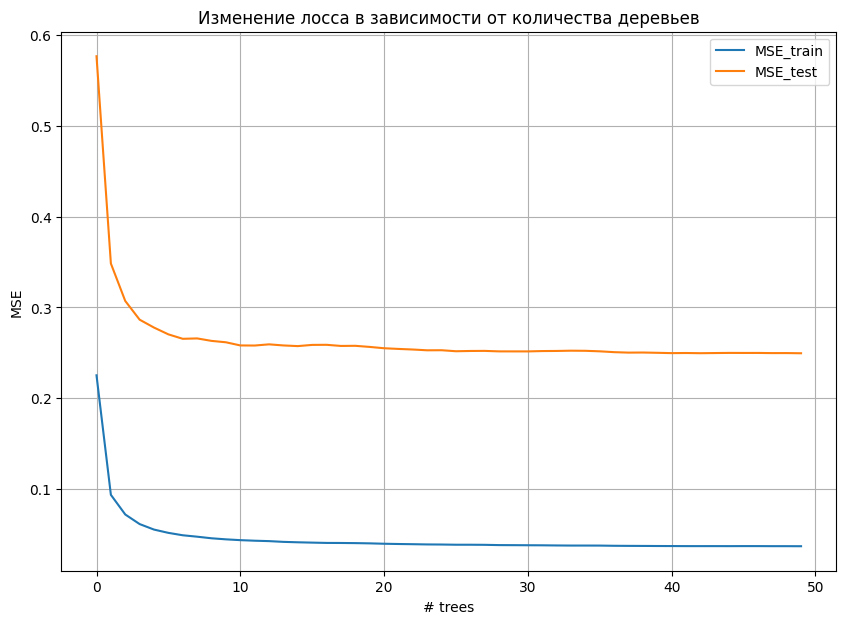

In [13]:
n_trees = 100
train_loss = []
test_loss = []

for i in trange(1, n_trees, 2):
    rf = RandomForestRegressor(n_estimators=i, random_state=123, n_jobs=4)
    rf.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, rf.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 7))
plt.title("Изменение лосса в зависимости от количества деревьев")
plt.grid()
plt.plot(train_loss, label="MSE_train")
plt.plot(test_loss, label="MSE_test")
plt.ylabel("MSE")
plt.xlabel("# trees")
plt.legend();

Как и ожидалось, по достижении некоторого числа деревьев обе ошибки практически не изменяются, то есть переобучения при росте числа деревьев не происходит. Однако практика показывает, что при изменении какого-нибудь другого параметра на реальных данных переобучение может произойти: [пример 1](https://datascience.stackexchange.com/questions/1028/do-random-forest-overfit), [пример 2](https://mljar.com/blog/random-forest-overfitting/). Например, случайный лес с ограниченными по глубине деревьями может предсказывать более точно, чем лес без ограничений. В нашем же случае случайный лес, скорее, лишь страдает от регуляризации. Например, посмотрим на поведение модели при изменении максимальной глубины деревьев (поэксперементируйте с другими параметрами).

100%|██████████| 25/25 [00:06<00:00,  4.08it/s]


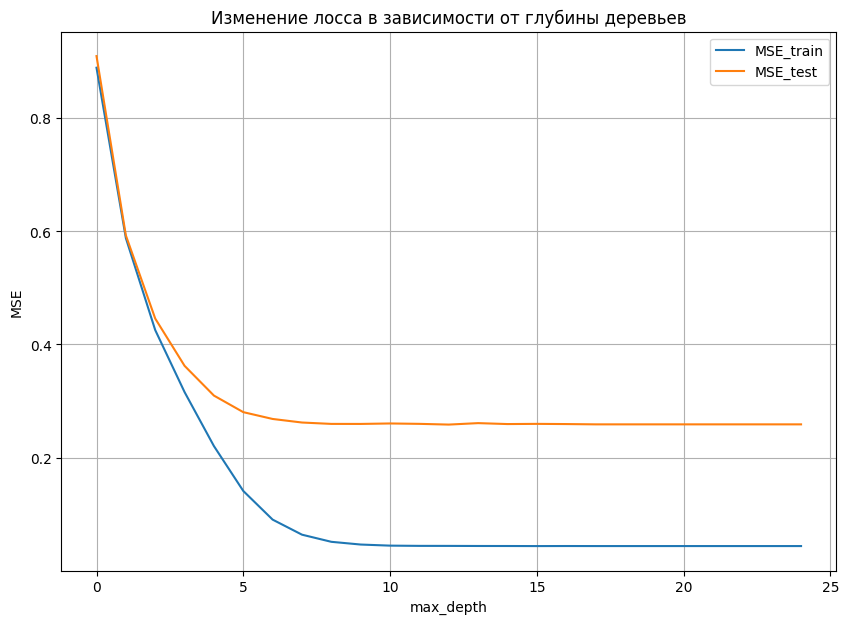

In [14]:
max_depth = 50
train_loss = []
test_loss = []

for i in trange(1, max_depth, 2):
    rf = RandomForestRegressor(n_estimators=20, max_depth=i, random_state=123, n_jobs=4)
    rf.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, rf.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, rf.predict(X_test)))

plt.figure(figsize=(10, 7))
plt.title("Изменение лосса в зависимости от глубины деревьев")
plt.grid()
plt.plot(train_loss, label="MSE_train")
plt.plot(test_loss, label="MSE_test")
plt.ylabel("MSE")
plt.xlabel("max_depth")
plt.legend();

Переобучение не наблюдается. Вообще же, как обычно, гиперпараметры случайного леса стоит подбирать на кросс-валидации.

### 3.2. Out-of-bag-ошибка

Как мы обсудили выше, при построении случайного леса каждое дерево строится на бутстрапированной подвыборке, полученной из исходной обучающей выборки случайным набором с повторениями. Понятно, что некоторые наблюдения попадут в такую подвыборку несколько раз, а некоторые не войдут в неё вообще. Для каждого дерева мы можем рассмотреть объекты, которые не участвовали в обучении и использовать их для валидации.

Усреднённая ошибка на неотобранных образцах по всему случайному лесу называется **out-of-bag-ошибкой**.

In [15]:
# oob_score_ = R2 на невиденных наблюдениях
rf = RandomForestRegressor(n_estimators=100, random_state=123, oob_score=True, n_jobs=4)
rf.fit(X_train, y_train)
rf.oob_score_

0.8004383841488338

### 3.3. Важность признаков
Как и решающие деревья, случайный лес позволяет оценивать важность признаков. Важность признаков можно оценивать, например, по тому, насколько сильно уменьшается хаотичность при применении предикатов на основе этого признака.

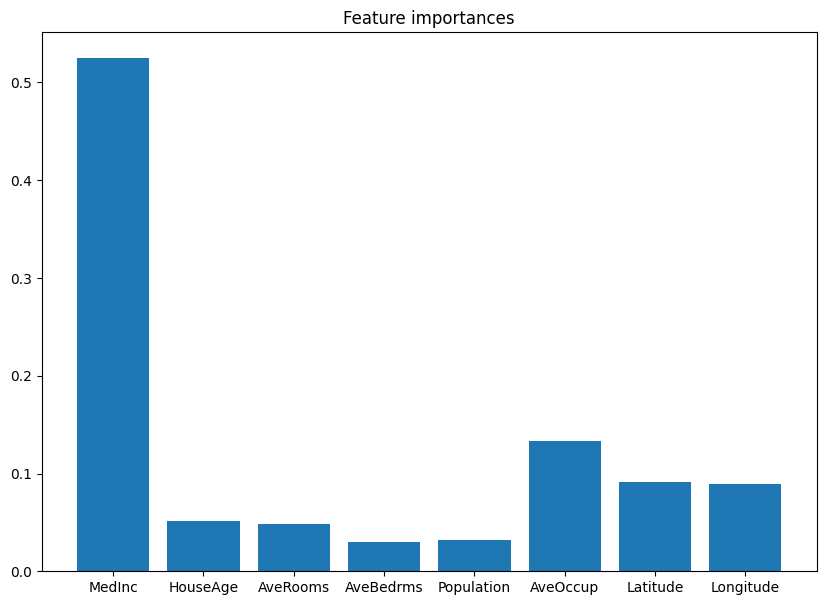

In [16]:
plt.figure(figsize=(10, 7))
plt.title("Feature importances")
plt.bar(california["feature_names"], rf.feature_importances_);

Будьте осторожны с сильно коррелирующими признаками. Посмотрим, что произойдёт с важностью, если добавить в выборку линейно зависимый признак.

In [17]:
RM_mc = np.array((X_train.iloc[:, 5] * 2 + 3)).reshape(-1, 1)
X_train_new = np.hstack((X_train, RM_mc))

In [18]:
rf.fit(X_train_new, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

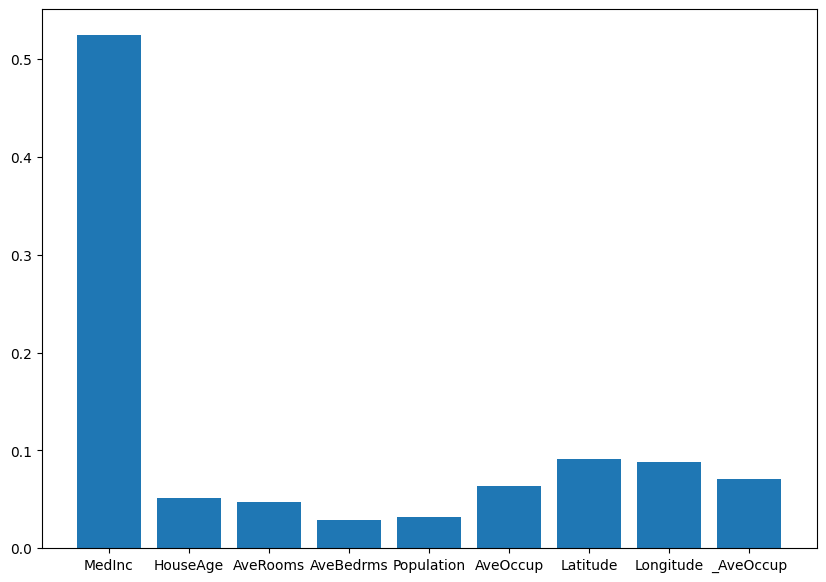

In [19]:
plt.figure(figsize=(10, 7))
names = list(california["feature_names"])
names.append("_AveOccup")
plt.bar(names, rf.feature_importances_);

Важности перераспределились между линейной зависимыми признаками `AveOccup` и `_AveOccup`. Не забывайте учитывать корреляции между признаками, если вы используете этот метод для отбора признаков. Также обратите внимание на предупреждение в документации `sklearn`: не стоит использовать этот метод и для признаков, в которых есть много уникальных значений (например, категориальные признаки с небольшим числом категорий).

## 4. Тестирование случайного леса на разных данных
Ниже представлены шаблоны для сравнения случайного леса и других моделей на данных разных типов. Проведите побольше экспериментов, используя разные модели и метрики. Попробуйте подобрать гиперпараметры случайного леса так, чтобы достичь какого-нибудь порога качества.

**NB: Случайный лес может обучаться достаточно долго.**

### 4.1. Бинарная классификация на примере [Kaggle Predicting a Biological Response](https://www.kaggle.com/c/bioresponse/data?select=train.csv)

In [ ]:
# Загрузка данных
# !wget  -O 'kaggle_response.csv' -q 'https://www.dropbox.com/s/uha70sej5ugcrur/_train_sem09.csv?dl=1'

zsh:1: command not found: wget


In [24]:
data = pd.read_csv("_train_sem09.csv")
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# TODO: обучите логистическую регрессию и случайный лес с дефолтными параметрами
# Сравните их AUC ROC на тестовой выборке
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print(
    f"Log reg AUC ROC score: {roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]):.2f}"
)
print(
    f"Random forest AUC ROC score: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.2f}"
)

Log reg AUC ROC score: 0.80
Random forest AUC ROC score: 0.88


### 4.2. Изображения на примере [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)

In [ ]:
import torchvision

fmnist = torchvision.datasets.FashionMNIST("./", download=True)
X, y = fmnist.data.numpy().reshape(-1, 28 * 28), fmnist.targets.numpy()

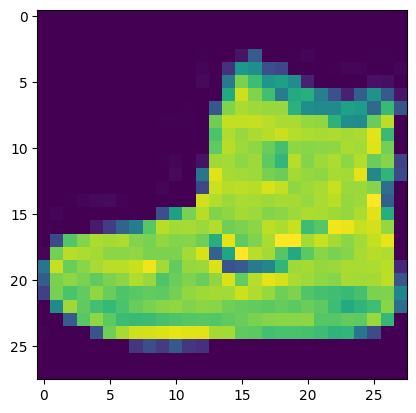

In [ ]:
plt.imshow(X[0, :].reshape(28, 28));

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# TODO: обучите случайный лес и kNN с дефолтными параметрами
# Сравните их доли правильных ответов на тестовой выборке
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print(f"kNN accuracy score: {accuracy_score(y_test, knn.predict(X_test)):.2f}")
print(f"Random forest accuracy score: {accuracy_score(y_test, rf.predict(X_test)):.2f}")

kNN accuracy score: 0.85
Random forest accuracy score: 0.88
